In [1]:
### Input parameters ###

folder = "/home/matsa/Desktop/PSB-OnDemand_TEMPORARY/_IN_USE/" 
haplotype_files = ["Plate1","Plate2","Plate3","Plate4","Plate5","Plate6","Plate7","Plate8","Plate9"]  #[]
experiment = "Run_1008"  #Name of the 'Sequencing experiment'

input_folder = folder + "inputs/"
output_folder = folder + "outputs/"

base_seq = "_haplotype_frequencies_c50_f2.0_m1.0.tsv"

genes = folder + "permanent_ref/KWS_target_genes.fasta" #Reference fasta file with all gene sequences
anchors = folder + "permanent_ref/KWS_borderFile.gff" #Reference gff file with the amplicon borders
plantnames = folder + "inputs/Run_1008p1-9_attributes.tsv" #All the plant names correspondence with the ILVO names
scriptdesign = folder + "permanent_ref/Script_design.csv" #csv file with the complete names of the Amplicons (including friendly names)

output_database_ONLY = "Database_" + experiment + "_ONLY.txt" #Name of the new part of the database (only current experiment)
breeding_table_ONLY = output_folder + "BREEDING_TABLE_" + experiment + ".xlsx" #Name of the Breeding table of current run (friendly excel format)
total_database = "DATABASE_KWS_plantHaplotypeFreq.txt" #Total database (HaplotypeFreq format) which is always updated
breeding_table_TOTAL = output_folder + "updated_after_" + experiment + "_BREEDING_TABLE.xlsx" #Name of the Total Breeding table (friendly excel format)


In [2]:
### Read in libraries ###
import re
import numpy as np
import pandas as pd
from Bio import SeqIO
import itertools
import matplotlib.pyplot as plt

In [3]:
### Merge function ###

def merge_files(files, base, input_folder):
    df = None
    for file in files:
        df_temp = pd.read_csv(input_folder + file + base , sep="\t")
        df_temp = pd.melt(df_temp, id_vars=['Reference', 'Locus', 'Haplotypes'], var_name="samples", value_name='freq')
        if df is None:
            df = df_temp
        else:
            df = pd.concat([df, df_temp], axis=0)
    
    df = pd.pivot_table(df, index=['Reference', 'Locus', 'Haplotypes'], columns="samples", values='freq', aggfunc='first', fill_value=None)
    df.reset_index(inplace=True)
    
    return df


### Table transformation functions ###

def get_ref_dict(gene_fasta, anchor_gff):
    ref_dict = {}
    fasta_dict = SeqIO.to_dict(SeqIO.parse(gene_fasta, "fasta"))   
    anchors = pd.read_csv(anchor_gff, sep="\t", header=None)
    
    anchors.columns=["gene_id", "tool", "direction", "start", "stop", "dot1", "sense", "dot2", "description"]
    anchors["gene_name"] = [i.split(' ')[0][5:] for i in anchors.loc[:,"description"]]
    
    gene_names = np.unique(anchors.loc[:,"gene_name"])

    for name in gene_names:
        spec_anchor = anchors.loc[(anchors.loc[:,"gene_name"] == name), :]
        gene_id = np.unique(spec_anchor["gene_id"])[0]
        
        start = int(spec_anchor.loc[((spec_anchor.loc[:,"direction"]=="border_up")|(spec_anchor.loc[:,"direction"]=="border_up")),"stop"])
        stop = int(spec_anchor.loc[((spec_anchor.loc[:,"direction"]=="border_down")|(spec_anchor.loc[:,"direction"]=="border_down")),"start"]) - 1
        ref_dict[name] = str(fasta_dict[gene_id].seq[start:stop])
        
    return ref_dict


def get_len_diff(gene_name, haplotype_seq, ref_dict):
    out = ''
    ref_haplotype = ref_dict[gene_name]
    if haplotype_seq == ref_haplotype:
        out = 'ref'
    else:
        out = str(len(haplotype_seq) - len(ref_haplotype))
    return out


def edit_to_category(edit):
    if edit == 'ref':
        return "REF"
    
    edit = int(edit)
    
    if edit == 0:
        return "SNP"
    
    if edit % 3 == 0:
        return "I_INDEL"
    
    return "O_INDEL"
    

### Modify the haplotype frequency table (1 experiment, all plates)

In [4]:
# Merge haplotype frequency files #
merged_haplotypes = merge_files(haplotype_files, base_seq, input_folder)
merged_haplotypes.to_csv(input_folder + "merged_plates_" + experiment + base_seq, sep="\t", na_rep='<NA>', index=False)

# Add identifier column for Experiment #
merged_haplotypes["Experiment"] = merged_haplotypes.apply(lambda x: experiment, axis=1) 
print("merged_haplotypes shape: " + str(merged_haplotypes.shape))
merged_haplotypes.head()


merged_haplotypes shape: (2495, 868)


samples,Reference,Locus,Haplotypes,100_009_260112_001_01932_103_001_1008,100_009_260112_001_01933_103_001_1008,100_009_260112_001_01934_103_001_1008,100_009_260112_001_01935_103_001_1008,100_009_260112_001_01936_103_001_1008,100_009_260112_001_01937_103_001_1008,100_009_260112_001_01938_103_001_1008,...,100_009_260112_001_02787_103_001_1008,100_009_260112_001_02788_103_001_1008,100_009_260112_001_02789_103_001_1008,100_009_260112_001_02790_103_001_1008,100_009_260112_001_02791_103_001_1008,100_009_260112_001_02792_103_001_1008,100_009_260112_001_02793_103_001_1008,100_009_260112_001_02794_103_001_1008,100_009_260112_001_02795_103_001_1008,Experiment
0,Cas9,Cas9_Amplicon1,GCTGTTCGTCGAGCAGCACAAGCATTACCTCGACGAGATCATTGAG...,100.00,100.00,100.0,100.00,100.00,100.00,100.00,...,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.0,Run_1008
1,Zm00001eb003440,Zm00001eb003440_Amplicon3,AGTCGGCATGGGCCCCGCCGGCGAGCTGCGCTACCCGTCCTACCCG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Run_1008
2,Zm00001eb003440,Zm00001eb003440_Amplicon3,AGTCGGCATGGGCCCCGCCGGCGAGCTGCGCTACCCGTCCTACCCG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.57,NaN,1.16,1.66,1.15,NaN,1.28,NaN,NaN,Run_1008
3,Zm00001eb003440,Zm00001eb003440_Amplicon3,AGTCGGCATGGGCCCTGCCGGCGAGCTGCGCTACCCGTCCTACCCG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.78,1.28,NaN,NaN,Run_1008
4,Zm00001eb003440,Zm00001eb003440_Amplicon3,GGTCGGCATGGGCCCCGCCGGCGAGCTGCGCTACCCGTCCTACCCG...,1.67,1.51,1.9,1.88,1.76,1.52,1.67,...,2.96,2.74,2.61,2.09,NaN,5.36,1.28,1.32,NaN,Run_1008


In [5]:
# Go from wide to long format #
haplotypes_long = merged_haplotypes.melt(id_vars=["Reference", "Locus", "Haplotypes","Experiment"], var_name="YIELD_name", value_name="Freq")


# Add the Edit and Category columns #
references = get_ref_dict(genes, anchors)

haplotypes_long["Edit"] = haplotypes_long.apply(lambda x: get_len_diff(x['Locus'], x['Haplotypes'], references), axis=1)
haplotypes_long["Category"] = haplotypes_long.apply(lambda x: edit_to_category(x['Edit']), axis=1)


# Read in the plantname dictionary #
naming = pd.read_csv(plantnames, sep = "\t")
#naming = naming.loc[:, ["YIELD_name", "plantName"]]

# Add the plantName column and Reorder columns (drop Reference column since it's redundant) #
haplotypes_long = haplotypes_long.merge(naming, on="YIELD_name")

haplotypes_long = haplotypes_long.loc[:,["Experiment", "YIELD_name", "plantName", "potNr", "Population","PlatePos",
                                         "Locus", "Edit", "Category", "Freq", "Haplotypes"]]



print("Expected shape: (" + str(merged_haplotypes.shape[0]*(merged_haplotypes.shape[1]-4)) + ", 8)")
print("Actual shape: " + str(haplotypes_long.shape))
haplotypes_long.head()


<ipython-input-3-f2a0060a1c70>:35: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  start = int(spec_anchor.loc[((spec_anchor.loc[:,"direction"]=="border_up")|(spec_anchor.loc[:,"direction"]=="border_up")),"stop"])
<ipython-input-3-f2a0060a1c70>:36: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  stop = int(spec_anchor.loc[((spec_anchor.loc[:,"direction"]=="border_down")|(spec_anchor.loc[:,"direction"]=="border_down")),"start"]) - 1


Expected shape: (2155680, 8)
Actual shape: (2155680, 11)


,Experiment,YIELD_name,plantName,potNr,Population,PlatePos,Locus,Edit,Category,Freq,Haplotypes
0,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,pheExp2_Pot1,P22_sb287,P1_A1,Cas9_Amplicon1,ref,REF,100.00,GCTGTTCGTCGAGCAGCACAAGCATTACCTCGACGAGATCATTGAG...
1,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,pheExp2_Pot1,P22_sb287,P1_A1,Zm00001eb003440_Amplicon3,0,SNP,NaN,AGTCGGCATGGGCCCCGCCGGCGAGCTGCGCTACCCGTCCTACCCG...
2,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,pheExp2_Pot1,P22_sb287,P1_A1,Zm00001eb003440_Amplicon3,0,SNP,NaN,AGTCGGCATGGGCCCCGCCGGCGAGCTGCGCTACCCGTCCTACCCG...
3,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,pheExp2_Pot1,P22_sb287,P1_A1,Zm00001eb003440_Amplicon3,0,SNP,NaN,AGTCGGCATGGGCCCTGCCGGCGAGCTGCGCTACCCGTCCTACCCG...
4,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,pheExp2_Pot1,P22_sb287,P1_A1,Zm00001eb003440_Amplicon3,0,SNP,1.67,GGTCGGCATGGGCCCCGCCGGCGAGCTGCGCTACCCGTCCTACCCG...


-- Before NaN removal --
max sum: 100.13000000000001
min sum: 0.0


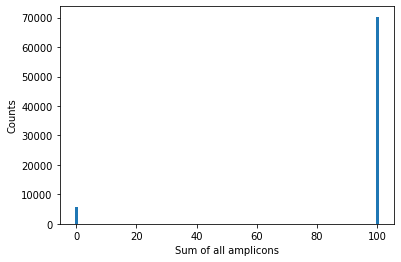

-- Bad amplicons --
['Zm00001eb003440_Amplicon3' 'Zm00001eb012040_Amplicon1'
 'Zm00001eb015620_Amplicon2' 'Zm00001eb016250_Amplicon1'
 'Zm00001eb016250_Amplicon2' 'Zm00001eb016290_Amplicon1'
 'Zm00001eb021270_Amplicon2' 'Zm00001eb021710_Amplicon1'
 'Zm00001eb050470_Amplicon1' 'Zm00001eb059930_Amplicon2'
 'Zm00001eb061880_Amplicon2' 'Zm00001eb061880_AmpliconOFF1'
 'Zm00001eb079430_AmpliconOFF1' 'Zm00001eb086700_Amplicon1'
 'Zm00001eb088070_Amplicon1' 'Zm00001eb089800_Amplicon1'
 'Zm00001eb098220_Amplicon1' 'Zm00001eb098630_AmpliconOFF1'
 'Zm00001eb105870_Amplicon3' 'Zm00001eb105870_AmpliconOFF1'
 'Zm00001eb122860_AmpliconOFF1' 'Zm00001eb122980_Amplicon1'
 'Zm00001eb124380_AmpliconOFF1' 'Zm00001eb124800_Amplicon3'
 'Zm00001eb126900_Amplicon1' 'Zm00001eb129290_Amplicon1'
 'Zm00001eb143050_Amplicon1' 'Zm00001eb148130_Amplicon1'
 'Zm00001eb156130_Amplicon1' 'Zm00001eb157860_Amplicon1'
 'Zm00001eb158020_Amplicon1' 'Zm00001eb159030_Amplicon1'
 'Zm00001eb159180_Amplicon1' 'Zm00001eb160470_Ampl

In [6]:
# Test wether the sum of freq Amplicon_Plant is ~100 #
test_df = haplotypes_long.copy(deep=True)
test_df_p = pd.pivot_table(test_df, values="Freq", index=["YIELD_name", "Locus"], aggfunc=np.sum).fillna(0)
test_df_p.reset_index(inplace=True)

max_num = max(test_df_p["Freq"])
min_num = min(test_df_p["Freq"])

print("-- Before NaN removal --")
print("max sum: " + str(max_num))
print("min sum: " + str(min_num))

%matplotlib inline
plt.hist(test_df_p["Freq"], bins=100, range=[min_num - 0.5, max_num + 0.5])
plt.xlabel("Sum of all amplicons")
plt.ylabel("Counts")
plt.show()


# Find the loci that did not yield any result during amplicon sequencing for some or all plants#
bad_amplicons_plants = test_df_p.loc[(test_df_p.loc[:, "Freq"] <= 10),:]
print("-- Bad amplicons --")
print(np.unique(bad_amplicons_plants["Locus"]))



shape before removing NaN: (2155680, 11)
NaN number: 1999321
Expected shape after: (156359, 11)
Actual shape after: (156359, 11)
-- After NaN removal --
max sum: 100.13000000000001
min sum: 99.86999999999999


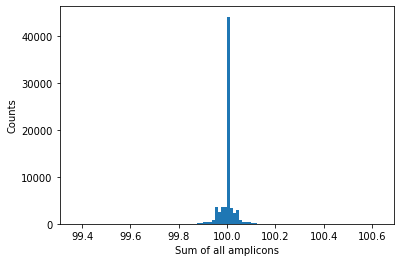

In [7]:
# Remove useless rows (Amplicon-Plant conjugations with NA freq) #
NaN_haplotypes = haplotypes_long.loc[haplotypes_long["Freq"].isna(), :]
NaN_nr = NaN_haplotypes.shape[0]

haplotypes_final = haplotypes_long.dropna(axis=0)

print("shape before removing NaN: " + str(haplotypes_long.shape))
print("NaN number: " + str(NaN_nr))
print("Expected shape after: (" + str(haplotypes_long.shape[0]-NaN_nr) + ", " + str(haplotypes_long.shape[1]) + ")")
print("Actual shape after: " + str(haplotypes_final.shape) )


# Test wether the sum of freq Amplicon_Plant is now ~100 for all the plants #
test_df2 = haplotypes_final.copy(deep=True)
test_df2_p = pd.pivot_table(test_df2, values="Freq", index=["YIELD_name", "plantName", "Locus"], aggfunc=np.sum).fillna(0)
test_df2_p.reset_index(inplace=True)

max_num = max(test_df2_p["Freq"])
min_num = min(test_df2_p["Freq"])

print("-- After NaN removal --")
print("max sum: " + str(max_num))
print("min sum: " + str(min_num))

%matplotlib inline
plt.hist(test_df2_p["Freq"], bins=100, range=[min_num - 0.5, max_num + 0.5])
plt.xlabel("Sum of all amplicons")
plt.ylabel("Counts")
plt.show()

### See some stats and control sample yield / sequencing quality

In [8]:
# See what types of Indel Edits exist #
print("-- Indel Edit Types --")
print(np.unique(haplotypes_final.loc[(haplotypes_final.loc[:, "Category"] == "I_INDEL"),:]["Edit"]))
print(np.unique(haplotypes_final.loc[(haplotypes_final.loc[:, "Category"] == "O_INDEL"),:]["Edit"]))

-- Indel Edit Types --
['-12' '-15' '-18' '-21' '-24' '-27' '-3' '-30' '-33' '-36' '-39' '-42'
 '-45' '-48' '-51' '-57' '-6' '-60' '-69' '-81' '-9' '-93' '12' '15' '18'
 '24' '27' '3' '36' '39' '48' '51' '6' '78' '9']
['-1' '-10' '-11' '-118' '-13' '-14' '-16' '-17' '-19' '-2' '-20' '-22'
 '-23' '-25' '-26' '-28' '-29' '-31' '-32' '-34' '-35' '-37' '-38' '-4'
 '-41' '-43' '-5' '-50' '-52' '-53' '-55' '-61' '-62' '-67' '-68' '-7'
 '-71' '-73' '-79' '-8' '-89' '-91' '1' '10' '104' '109' '11' '13' '14'
 '16' '17' '19' '2' '22' '26' '29' '34' '4' '5' '50' '62' '7' '8' '86']


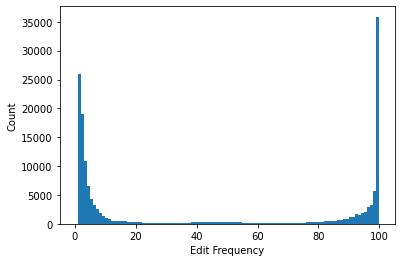

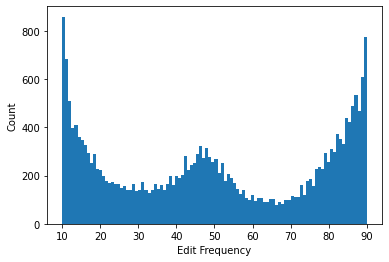

In [9]:
%matplotlib inline
# Create Images for manual checking PART1 #
plt.hist((haplotypes_final["Freq"]), range=(0,100), bins=100)
plt.xlabel("Edit Frequency")
plt.ylabel("Count")
plt.show()

# Create Images for manual checking PART2 #
plt.hist((haplotypes_final["Freq"]), range=(10,90), bins=100)
plt.xlabel("Edit Frequency")
plt.ylabel("Count")
plt.show()

### Create the breeding table of the Experiment 

In [10]:
# Pivot the database table by category, Freq representing TOTAL Freq #
haplotypes_final_p = pd.pivot_table(haplotypes_final, values='Freq', index=['Experiment','YIELD_name', 'plantName', 'Population', 'potNr', 'PlatePos', 'Locus'], columns=['Category'], aggfunc=np.sum, fill_value=0)
haplotypes_final_p.reset_index(inplace=True) #this resets the index so the YIELD_name and Locus can be used as normal columns

print("Targeted length: ", len(np.unique(haplotypes_final["YIELD_name"] + "&" + haplotypes_final["Locus"])))
print("Actual length: ", haplotypes_final_p.shape[0])

haplotypes_final_p.head()

Targeted length:  70321
Actual length:  70321


Category,Experiment,YIELD_name,plantName,Population,potNr,PlatePos,Locus,I_INDEL,O_INDEL,REF,SNP
0,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,P22_sb287,pheExp2_Pot1,P1_A1,Cas9_Amplicon1,0.0,0.0,100.00,0.00
1,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,P22_sb287,pheExp2_Pot1,P1_A1,Zm00001eb003440_Amplicon3,0.0,0.0,92.75,7.25
2,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,P22_sb287,pheExp2_Pot1,P1_A1,Zm00001eb012040_Amplicon1,0.0,0.0,98.00,2.01
3,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,P22_sb287,pheExp2_Pot1,P1_A1,Zm00001eb016250_Amplicon1,0.0,0.0,100.00,0.00
4,Run_1008,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,P22_sb287,pheExp2_Pot1,P1_A1,Zm00001eb016290_Amplicon1,0.0,0.0,100.00,0.00


In [11]:
# Back-pivot the table by locus #
breeding_table = pd.pivot(haplotypes_final_p, index=["Experiment", "PlatePos", "YIELD_name", "plantName", "Population", "potNr"], 
                            columns=["Locus"], values=["REF","O_INDEL", "I_INDEL", "SNP"])
breeding_table.reset_index(inplace=True)


# Correct column names (three changes) #
#1 Append edit category
column_names=breeding_table.columns
column_names_new = ["Experiment", "PlatePos", "YIELD_name", "plantName", "Population", "potNr"] + [f"{value[1]}_{value[0]}" for value in column_names if value[0] in ['REF', 'SNP', 'O_INDEL', 'I_INDEL']]
breeding_table.columns = column_names_new

#2 Add the script and friendly names of each amplicon
correspondence_df = pd.read_csv(scriptdesign, sep=";")
correspondence_dict = correspondence_df.set_index('B73 V5 ID').T.to_dict('list')
for key in correspondence_dict:
    parts = correspondence_dict[key][2].split('_')
    correspondence_dict[key][2] = '_'.join(parts[:2])
    correspondence_dict[key] = [correspondence_dict[key][2]]

def rename_column(col):
    parts = col.split('_')
    geneID = parts[0]
    if geneID in correspondence_dict:
        Locus = correspondence_dict[geneID]
        new_col = f"{Locus}_{col}"
        new_col = new_col.replace('Amplicon', '')
        new_col = new_col.replace("']", '')
        new_col = new_col.replace("['", '')
        return new_col
    return col

columns_to_rename = breeding_table.columns[6:]   #Select columns to rename (from 6th column to the end)
renamed_columns = {col: rename_column(col) for col in columns_to_rename}
breeding_table.rename(columns=renamed_columns, inplace=True)

#3 Manually correct names of SUS2.2 and HIPP.1 Amplicons
all_columns_renamed = (
    breeding_table.columns
        .str.replace("Zm00001eb016250_2", "Zm00001eb016250_OFF2")
        .str.replace("Zm00001eb198790_OFF1", "Zm00001eb198790_1")
        .str.replace("Zm00001eb198790_3", "Zm00001eb198790_OFF3")
)

breeding_table.columns = all_columns_renamed


In [12]:
## Remove FAKE OFFTARGETS forever
fake_offtargets_longnames = ['OFF_Zm00001eb098220_Amplicon1_I_INDEL','OFF_Zm00001eb098220_Amplicon1_O_INDEL','OFF_Zm00001eb098220_Amplicon1_SNP','OFF_Zm00001eb098220_Amplicon1_REF',
                   'OFF_Zm00001eb159180_Amplicon1_I_INDEL','OFF_Zm00001eb159180_Amplicon1_O_INDEL','OFF_Zm00001eb159180_Amplicon1_SNP','OFF_Zm00001eb159180_Amplicon1_REF',
                   'OFF_RAFS2_Zm00001eb303190_OFF1_I_INDEL','OFF_RAFS2_Zm00001eb303190_OFF1_O_INDEL','OFF_RAFS2_Zm00001eb303190_OFF1_SNP','OFF_RAFS2_Zm00001eb303190_OFF1_REF',
                   'OFF_Zm00001eb309920_Amplicon2_I_INDEL','OFF_Zm00001eb309920_Amplicon2_O_INDEL','OFF_Zm00001eb309920_Amplicon2_SNP','OFF_Zm00001eb309920_Amplicon2_REF',
                   'OFF_Zm00001eb314860_AmpliconOFF1_I_INDEL','OFF_Zm00001eb314860_AmpliconOFF1_O_INDEL','OFF_Zm00001eb314860_AmpliconOFF1_SNP','OFF_Zm00001eb314860_AmpliconOFF1_REF',
                   'OFF_Zm00001eb337450_Amplicon2_I_INDEL','OFF_Zm00001eb337450_Amplicon2_O_INDEL','OFF_Zm00001eb337450_Amplicon2_SNP','OFF_Zm00001eb337450_Amplicon2_REF',
                   'OFF_Zm00001eb281720_AmpliconOFF1_I_INDEL','OFF_Zm00001eb281720_AmpliconOFF1_O_INDEL','OFF_Zm00001eb281720_AmpliconOFF1_SNP','OFF_Zm00001eb281720_AmpliconOFF1_REF']
breeding_table = breeding_table.drop(columns=fake_offtargets_longnames, errors="ignore")   ##or fake_offtargets_longnames if that's how it is in the dataset


# Sort columns alphabetically, and Amplicon OFF to the end #
columns_with_off = [col for col in breeding_table.columns[6:] if '_OFF' in col]
columns_without_off = [col for col in breeding_table.columns[6:] if '_OFF' not in col]
columns_without_off.sort()
sorted_columns = list(breeding_table.columns[:6]) + columns_without_off + columns_with_off
breeding_table = breeding_table[sorted_columns]

breeding_table.head()

,Experiment,PlatePos,YIELD_name,plantName,Population,potNr,Cas9_Amplicon1_I_INDEL,Cas9_Amplicon1_O_INDEL,Cas9_Amplicon1_REF,Cas9_Amplicon1_SNP,...,S1_PRH132_Zm00001eb357040_OFF1_I_INDEL,S2_SUS2.2_Zm00001eb016250_OFF2_SNP,S5_ACO5_Zm00001eb105870_OFF1_SNP,S5_MTL3_Zm00001eb124380_OFF1_SNP,S4_HIPP.1_Zm00001eb198790_OFF3_SNP,S2_BAM1_Zm00001eb222250_OFF1_SNP,S1_PP2C.A10_Zm00001eb294200_OFF1_SNP,S3_GBF3_Zm00001eb296340_OFF1_SNP,S2_RAFS2_Zm00001eb303190_OFF1_SNP,S1_PRH132_Zm00001eb357040_OFF1_SNP
0,Run_1008,P1_A1,100_009_260112_001_01932_103_001_1008,T3_S1S2S3S5_KS2392,P22_sb287,pheExp2_Pot1,0.0,0.0,100.0,0.0,...,0.0,NaN,0.0,NaN,0.0,0.0,0.00,18.72,0.0,3.67
1,Run_1008,P1_A10,100_009_260112_001_01941_103_001_1008,T3_S1S5_KS2464,P16_sb286,pheExp2_Pot73,0.0,0.0,100.0,0.0,...,0.0,NaN,0.0,NaN,NaN,0.0,0.00,38.60,0.0,2.55
2,Run_1008,P1_A11,100_009_260112_001_01942_103_001_1008,T3_S1S2S3S5_KS2472,P21_sb288,pheExp2_Pot81,0.0,0.0,100.0,0.0,...,0.0,NaN,0.0,NaN,0.0,0.0,0.00,26.11,0.0,1.12
3,Run_1008,P1_A12,100_009_260112_001_01943_103_001_1008,T3_S1S4_KS2480,P14_sb289,pheExp2_Pot89,0.0,0.0,100.0,0.0,...,0.0,NaN,0.0,NaN,NaN,0.0,0.00,17.95,0.0,0.00
4,Run_1008,P1_A2,100_009_260112_001_01933_103_001_1008,T3_S1S5_KS2400,P16_sb286,pheExp2_Pot9,0.0,0.0,100.0,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,4.12,33.74,0.0,2.10


In [13]:
# Create some different tables for different views #
#cols_MUT = ["plantName", "Population", "potNr"] + [i for i in breeding_table.columns[5:] if ((i.endswith("_O_INDEL")) | (i.endswith("_I_INDEL")) | (i.endswith("_SNP")))]
#cols_INDEL = ["plantName", "Population", "potNr"] + [i for i in breeding_table.columns[5:] if ((i.endswith("_O_INDEL")) | (i.endswith("_I_INDEL")))]
cols_O = ["plantName", "Population", "potNr"] + [i for i in breeding_table.columns[6:] if (i.endswith("_O_INDEL"))]
cols_I = ["plantName", "Population", "potNr"] + [i for i in breeding_table.columns[6:] if (i.endswith("_I_INDEL"))]
cols_S = ["plantName", "Population", "potNr"] + [i for i in breeding_table.columns[6:] if (i.endswith("_SNP"))]
cols_R = ["plantName", "Population", "potNr"] + [i for i in breeding_table.columns[6:] if (i.endswith("_REF"))]

In [14]:
# Write out the output #
with pd.ExcelWriter(breeding_table_ONLY) as writer:
    breeding_table.to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="Overview")
    #breeding_table.loc[:,cols_MUT].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="Mutated")
    #breeding_table.loc[:,cols_INDEL].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="INDEL")
    breeding_table.loc[:,cols_O].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="O_INDEL")
    breeding_table.loc[:,cols_I].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="I_INDEL")
    breeding_table.loc[:,cols_S].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="SNP")
    breeding_table.loc[:,cols_R].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="REF")

### Add the new database to the old database (Haplotype Frequency + Edit Type)

In [15]:
# Read in the old database #
exist_database = pd.read_csv(input_folder + "DATABASE_KWS_plantHaplotypeFreq.txt", sep = "\t")
exist_database = exist_database.loc[:,["Experiment", "YIELD_name", "plantName", "Locus", "Edit", "Category", "Freq", "Haplotypes"]] #Remove unwanted columns
NEW_database = haplotypes_final.loc[:,["Experiment", "YIELD_name", "plantName", "Locus", "Edit", "Category", "Freq", "Haplotypes"]]

# Merge the new with the old database #
mer_database = pd.concat([exist_database, NEW_database], axis=0, ignore_index=True)
print("Existing database shape: " + str(exist_database.shape))
print("New experiment shape: " + str(NEW_database.shape))
print("Merged Database shape: " + str(mer_database.shape))

# Remove duplicate lines #
duplicate_counts = mer_database.groupby(list(mer_database.columns)).size().reset_index(name='Count')
duplicates = duplicate_counts[duplicate_counts['Count'] > 1]
print("Nr of duplicated rows: " + str(len(duplicates)))
new_database = mer_database.drop_duplicates()
print("New Database shape: " + str(new_database.shape))
new_database.head()


Existing database shape: (309122, 8)
New experiment shape: (156359, 8)
Merged Database shape: (465481, 8)
Nr of duplicated rows: 0
New Database shape: (465481, 8)


,Experiment,YIELD_name,plantName,Locus,Edit,Category,Freq,Haplotypes
0,Run_1003,100_004_240910_001_00338_103_001_1003,T0_S2_KS00157,Cas9_Amplicon1,ref,REF,100.00,GCTGTTCGTCGAGCAGCACAAGCATTACCTCGACGAGATCATTGAG...
1,Run_1003,100_004_240910_001_00338_103_001_1003,T0_S2_KS00157,Zm00001eb003440_Amplicon3,ref,REF,100.00,GGTCGGCATGGGCCCTGCCGGCGAGCTGCGCTACCCGTCCTACCCG...
2,Run_1003,100_004_240910_001_00338_103_001_1003,T0_S2_KS00157,Zm00001eb012040_Amplicon1,0,SNP,3.00,AATTCTTCTTCATGTGCATCACGCAGGTGGCGACGTCGTGCGGGGA...
3,Run_1003,100_004_240910_001_00338_103_001_1003,T0_S2_KS00157,Zm00001eb012040_Amplicon1,ref,REF,96.94,AATTCTTCTTCATGTGCATCACGCAGGTGGCGACGTCGTGCGGGGA...
4,Run_1003,100_004_240910_001_00338_103_001_1003,T0_S2_KS00157,Zm00001eb016250_Amplicon1,1,O_INDEL,15.84,CGCGTCAACGTTCACGAGCTCAGCGTCGAGCAGCTCACAGTCTCGG...


In [16]:
# Save the new database #
new_database.to_csv(output_folder + total_database, sep="\t", index=False)
haplotypes_final.to_csv(output_folder + output_database_ONLY, sep="\t", index=False)

### Create the updated breeding table (all Experiments)

In [17]:
# Assign RunXXXX to rows without Experiment number #
new_database.loc[:,'Experiment'].fillna('RunXXXX')

# Pivot the database table by category #
new_database_p = pd.pivot_table(new_database, values='Freq', index=['Experiment','YIELD_name', 'plantName', 'Locus'], 
                                columns=['Category'], aggfunc=np.sum, fill_value=0)
new_database_p.reset_index(inplace=True) 

print("Targeted length: ", len(np.unique(new_database["YIELD_name"] + "&" + new_database["Locus"])))
print("Actual length: ", new_database_p.shape[0])


Targeted length:  218180
Actual length:  218180


In [18]:
# Back-pivot the table by locus #
total_breeding_table = pd.pivot(new_database_p, index=["Experiment", "YIELD_name", "plantName"], 
                            columns=["Locus"], values=["REF","O_INDEL", "I_INDEL", "SNP"])
total_breeding_table.reset_index(inplace=True)


# Correct column names (two changes) #
#1 Append edit category
column_names=total_breeding_table.columns
column_names_new = ["Experiment", "YIELD_name", "plantName"] + [f"{value[1]}_{value[0]}" for value in column_names if value[0] in ['REF', 'SNP', 'O_INDEL', 'I_INDEL']]
total_breeding_table.columns = column_names_new

#2 Add the script and friendly names of each amplicon
correspondence_df = pd.read_csv(scriptdesign, sep=";")
correspondence_dict = correspondence_df.set_index('B73 V5 ID').T.to_dict('list')
for key in correspondence_dict:
    parts = correspondence_dict[key][2].split('_')
    correspondence_dict[key][2] = '_'.join(parts[:2])
    correspondence_dict[key] = [correspondence_dict[key][2]]

columns_to_rename = total_breeding_table.columns[3:]   #Select columns to rename (from 4th column to the end)
renamed_columns = {col: rename_column(col) for col in columns_to_rename}
total_breeding_table.rename(columns=renamed_columns, inplace=True)


# Sort columns alphabetically, and Amplicon OFF to the end #
columns_with_off = [col for col in total_breeding_table.columns[3:] if '_OFF' in col]
columns_without_off = [col for col in total_breeding_table.columns[3:] if '_OFF' not in col]
columns_without_off.sort()
sorted_columns = list(total_breeding_table.columns[:3]) + columns_without_off + columns_with_off
total_breeding_table = total_breeding_table[sorted_columns]


# Create some different tables for different views #
cols_MUT = ["plantName"] + [i for i in total_breeding_table.columns[2:] if ((i.endswith("_O_INDEL")) | (i.endswith("_I_INDEL")) | (i.endswith("_SNP")))]
cols_INDEL = ["plantName"] + [i for i in total_breeding_table.columns[2:] if ((i.endswith("_O_INDEL")) | (i.endswith("_I_INDEL")))]
cols_O = ["plantName"] + [i for i in total_breeding_table.columns[2:] if (i.endswith("_O_INDEL"))]
cols_I = ["plantName"] + [i for i in total_breeding_table.columns[2:] if (i.endswith("_I_INDEL"))]
cols_S = ["plantName"] + [i for i in total_breeding_table.columns[2:] if (i.endswith("_SNP"))]
cols_R = ["plantName"] + [i for i in total_breeding_table.columns[2:] if (i.endswith("_REF"))]

# Write out the output #
with pd.ExcelWriter(breeding_table_TOTAL) as writer:
    total_breeding_table.to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="Overview")
#    total_breeding_table.loc[:,cols_MUT].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="Mutated")
#    total_breeding_table.loc[:,cols_INDEL].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="INDEL")
    total_breeding_table.loc[:,cols_O].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="O_INDEL")
    total_breeding_table.loc[:,cols_I].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="I_INDEL")
    total_breeding_table.loc[:,cols_S].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="SNP")
    total_breeding_table.loc[:,cols_R].to_excel(writer, header=True, index_label=None, index=False, freeze_panes=(1,2), na_rep="NA", sheet_name="REF")

### Create the table of MaxFreq per Category 

In [19]:
# Pivot the database table by category, Freq representing MAX Freq #
maxhaplotypes_p = pd.pivot_table(haplotypes_final, values='Freq', index=['Experiment','YIELD_name', 'plantName', 'Locus'], columns=['Category'], aggfunc=np.max, fill_value=0)
maxhaplotypes_p.reset_index(inplace=True)
maxhaplotypes_p.rename(columns={'I_INDEL': 'I_INDEL_maxfreq', 
                                'O_INDEL': 'O_INDEL_maxfreq',
                                'SNP': 'SNP_maxfreq'}, inplace=True)
maxhaplotypes_p.drop(columns=['REF'], inplace=True)


#This table can be merged to the haplotypes_final_p table, and a direct comparison between the totalFreq and maxFreq for each plant, amplicon and category
#(+ alert when there is a big discrepancy ---> meaning the edit Freq is being overestimated)
discrepancy_table = haplotypes_final_p.merge(maxhaplotypes_p, on=['Experiment','YIELD_name','plantName', 'Locus'], how='left')
discrepancy_table['Instance'] = discrepancy_table.apply(lambda row: f"{row['plantName']}_{row['Locus']}", axis=1)

discrepancy_table['I_INDEL_dif'] = discrepancy_table['I_INDEL'] - discrepancy_table['I_INDEL_maxfreq']
discrepancy_table['O_INDEL_dif'] = discrepancy_table['O_INDEL'] - discrepancy_table['O_INDEL_maxfreq']
discrepancy_table['SNP_dif'] = discrepancy_table['SNP'] - discrepancy_table['SNP_maxfreq']

discrepancy_table = discrepancy_table[['Instance','O_INDEL_dif','I_INDEL_dif','SNP_dif']]

discrepant_IINDELS = discrepancy_table.loc[discrepancy_table['I_INDEL_dif'] > 10, 'Instance'].tolist()
discrepant_OINDELS = discrepancy_table.loc[discrepancy_table['O_INDEL_dif'] > 10, 'Instance'].tolist()
discrepant_SNPS = discrepancy_table.loc[discrepancy_table['SNP_dif'] > 10, 'Instance'].tolist()

discrepant_OINDELS = [item.replace('Amplicon', '') for item in discrepant_OINDELS]
discrepant_OINDELS = [item.replace('T0_', '') for item in discrepant_OINDELS]
print("Attention to the following " + str(len(discrepant_OINDELS)) +
     " O_INDELs: " + str(discrepant_OINDELS))

discrepancy_table.head()
discrepancy_table.to_csv('./outputs/DiscrepancyTable.csv', index=False) 

Attention to the following 1651 O_INDELs: ['T3_S1S5_KS2400_Zm00001eb126900_1', 'T3_S1S5_KS2408_Zm00001eb124380_2', 'T3_S1S5_KS2408_Zm00001eb336760_3', 'T3_S1S2S3S5_KS2416_Zm00001eb158020_1', 'T3_S1S2S3S5_KS2416_Zm00001eb404560_1', 'T3_S3_KS2432_Zm00001eb178990_1', 'T3_S3_KS2440_Zm00001eb178990_1', 'T3_S1S5_KS2464_Zm00001eb089800_1', 'T3_S1S5_KS2464_Zm00001eb124800_3', 'T3_S1S5_KS2464_Zm00001eb249520_1', 'T3_S1S5_KS2464_Zm00001eb279120_2', 'T3_S1S5_KS2464_Zm00001eb296340_2', 'T3_S1S5_KS2464_Zm00001eb350120_1', 'T3_S1S5_KS2464_Zm00001eb404560_1', 'T3_S1S5_KS2464_Zm00001eb409910_1', 'T3_S1S2S3S5_KS2472_Zm00001eb158020_1', 'T3_S1S4_KS2480_Zm00001eb119440_3', 'T3_S1S4_KS2480_Zm00001eb158020_1', 'T3_S1S4_KS2480_Zm00001eb198790_OFF1', 'T3_S1S4_KS2480_Zm00001eb254100_1', 'T3_S1S4_KS2480_Zm00001eb344210_1', 'T3_S1S4_KS2480_Zm00001eb357040_1', 'T3_S1S4_KS2480_Zm00001eb357040_OFF1', 'T3_S1S4_KS2480_Zm00001eb367840_1', 'T3_S3_KS2393_Zm00001eb178990_1', 'T3_S3S4_KS2401_Zm00001eb159030_1', 'T3_S3S4_

### Create the table of nr of haplotypes per Locus per plant and nr haplotypes with Freq>20%

In [20]:
# Pivot the database table by category count nr Haplotypes #
totnrhaplotypes_p = pd.pivot_table(haplotypes_final, 
                                   values='Freq', 
                                   index=['Experiment', 'plantName', 'Locus'], 
                                   columns=['Category'], 
                                   aggfunc="count", fill_value=0)
totnrhaplotypes_p.reset_index(inplace=True)
totnrhaplotypes_p.rename(columns={'I_INDEL': 'I_INDEL_TotalNrHaplotypes', 
                                'O_INDEL': 'O_INDEL_TotalNrHaplotypes',
                                'SNP': 'SNP_TotalNrHaplotypes'}, inplace=True)
totnrhaplotypes_p.drop(columns=['REF'], inplace=True)

# Pivot the database table by category count nr Haplotypes with Freq>20 #
nrhaplotypes20_p = pd.pivot_table(haplotypes_final[haplotypes_final['Freq']>20], 
                                   values='Freq', 
                                   index=['Experiment', 'plantName', 'Locus'], 
                                   columns=['Category'], 
                                   aggfunc="count", fill_value=0)
nrhaplotypes20_p.reset_index(inplace=True)
nrhaplotypes20_p.rename(columns={'I_INDEL': 'I_INDEL_NrHaplotypesFreq>0', 
                                'O_INDEL': 'O_INDEL_NrHaplotypesFreq>20',
                                'SNP': 'SNP_NrHaplotypesFreq>20'}, inplace=True)
nrhaplotypes20_p.drop(columns=['REF'], inplace=True)

In [21]:
totnrhaplotypes_p.head()

Category,Experiment,plantName,Locus,I_INDEL_TotalNrHaplotypes,O_INDEL_TotalNrHaplotypes,SNP_TotalNrHaplotypes
0,Run_1008,ED1__KS2404,Cas9_Amplicon1,0,0,0
1,Run_1008,ED1__KS2404,Zm00001eb003440_Amplicon3,0,0,2
2,Run_1008,ED1__KS2404,Zm00001eb012040_Amplicon1,0,0,0
3,Run_1008,ED1__KS2404,Zm00001eb016250_Amplicon1,0,0,0
4,Run_1008,ED1__KS2404,Zm00001eb016290_Amplicon1,0,0,0


In [22]:
# Pivot the database table by category, Freq representing MAX Freq #
totfreq_p = pd.pivot_table(haplotypes_final[haplotypes_final['Category']=="O_INDEL"], 
                           values='Freq', 
                           index=['Experiment','plantName', 'Locus'], columns=['Category'], aggfunc=np.sum, fill_value=0)
totfreq_p.reset_index(inplace=True)
totfreq_p.rename(columns={'O_INDEL': 'O_INDEL_totfreq'}, inplace=True)


#Merge all info refering to O_INDELs
hapdiversity_table = totfreq_p.merge(maxhaplotypes_p, on=['Experiment','plantName', 'Locus'], how='left')
hapdiversity_table = hapdiversity_table.merge(totnrhaplotypes_p, on=['Experiment','plantName', 'Locus'], how='left')
hapdiversity_table = hapdiversity_table.merge(nrhaplotypes20_p, on=['Experiment','plantName', 'Locus'], how='left')[['Experiment','plantName', 'Locus','O_INDEL_totfreq','O_INDEL_maxfreq','O_INDEL_TotalNrHaplotypes','O_INDEL_NrHaplotypesFreq>20']]


hapdiversity_table = hapdiversity_table.rename(columns={'O_INDEL_totfreq':'Collapsed Freq',
                                                        'O_INDEL_maxfreq':'MaxFreq Haplotype',
                                                        'O_INDEL_TotalNrHaplotypes':'Nr Haplotypes',
                                                        'O_INDEL_NrHaplotypesFreq>20':'Haplotypes above 20% Freq'})

hapdiversity_table.head()


Category,Experiment,plantName,Locus,Collapsed Freq,MaxFreq Haplotype,Nr Haplotypes,Haplotypes above 20% Freq
0,Run_1008,ED1__KS2404,Zm00001eb158020_Amplicon1,1.61,1.61,1,0.0
1,Run_1008,ED1__KS2404,Zm00001eb335880_Amplicon2,1.85,1.85,1,0.0
2,Run_1008,ED1__KS2404,Zm00001eb374090_Amplicon3,1.42,1.42,1,0.0
3,Run_1008,ED1__KS2421,Zm00001eb050470_Amplicon1,4.11,4.11,1,0.0
4,Run_1008,ED1__KS2421,Zm00001eb059930_Amplicon2,2.46,2.46,1,0.0


In [23]:
import csv
with open('./outputs/HapDiversityTable.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(hapdiversity_table)

In [24]:
hapdiversity_table.to_csv('./outputs/HapDiversityTable.csv', index=False) 